In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import re

In [2]:
df = pd.read_csv(r"D:\Work\ADB\SAR\datasets\paper figures\SVNM_rice_cycles.csv")
geom = gpd.points_from_xy(df.lon, df.lat)
gdf = gpd.GeoDataFrame(df[['id', 'cycles']], geometry=geom)
poly = gpd.read_file(r"D:\Work\ADB\SAR\shapefiles\gadm41_VNM_1.json")
poly = poly[poly['VARNAME_1'].isin(['LongAn', 'DongThap', 'TienGiang', 'AnGiang', 'CanTho', 'VinhLong',
                                    'BenTre', 'KienGiang', 'HauGiang', 'TraVinh', 'SocTrang', 'BacLieu', 'CaMau',
                                    'BinhPhuoc', 'TayNinh', 'BinhDuong', 'DongNai', 'BaRia-VungTau', 'HoChiMinh'])]
poly['NAME_1_EN'] = poly['VARNAME_1'].apply(lambda x: re.sub(r'([a-z])([A-Z])', r'\1 \2', x))
# poly[poly['VARNAME_1'].str.contains('Phu')]
poly['centroid_x'] = poly.centroid.x
poly['centroid_y'] = poly.centroid.y
poly

C:\Users\sonle\AppData\Local\Temp\ipykernel_59568\1191239652.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poly['centroid_x'] = poly.centroid.x
C:\Users\sonle\AppData\Local\Temp\ipykernel_59568\1191239652.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poly['centroid_y'] = poly.centroid.y


,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,NAME_1_EN,centroid_x,centroid_y
0,VNM.1_1,VNM,Vietnam,AnGiang,AnGiang,NA,Tỉnh,Province,NA,VN.AG,VN-44,"MULTIPOLYGON (((105.54860 10.42950, 105.54950 ...",An Giang,105.182773,10.511371
1,VNM.7_1,VNM,Vietnam,BàRịa-VũngTàu,BaRia-VungTau,NA,Tỉnh,Province,NA,VN.BV,NA,"MULTIPOLYGON (((107.09010 10.32400, 107.08890 ...",Ba Ria-Vung Tau,107.279502,10.582012
4,VNM.2_1,VNM,Vietnam,BạcLiêu,BacLieu,NA,Tỉnh,Province,NA,VN.BL,NA,"MULTIPOLYGON (((105.42440 9.02130, 105.41640 9...",Bac Lieu,105.489169,9.313862
6,VNM.6_1,VNM,Vietnam,BếnTre,BenTre,NA,Tỉnh,Province,NA,VN.BR,NA,"MULTIPOLYGON (((106.71900 10.03370, 106.70860 ...",Ben Tre,106.468302,10.119457
8,VNM.9_1,VNM,Vietnam,BìnhDương,BinhDuong,NA,Tỉnh,Province,NA,VN.BI,NA,"MULTIPOLYGON (((106.76130 10.87460, 106.76040 ...",Binh Duong,106.658283,11.216947
9,VNM.10_1,VNM,Vietnam,BìnhPhước,BinhPhuoc,NA,Tỉnh,Province,NA,VN.BP,NA,"MULTIPOLYGON (((106.86650 11.31350, 106.86610 ...",Binh Phuoc,106.908231,11.755396
11,VNM.13_1,VNM,Vietnam,CàMau,CaMau,NA,Tỉnh,Province,NA,VN.CM,NA,"MULTIPOLYGON (((104.85350 8.42020, 104.85760 8...",Ca Mau,105.040505,9.049514
12,VNM.12_1,VNM,Vietnam,CầnThơ,CanTho,NA,Thànhphố,City,NA,VN.CN,NA,"MULTIPOLYGON (((105.56960 9.98390, 105.56310 9...",Can Tho,105.530496,10.114499
18,VNM.17_1,VNM,Vietnam,ĐồngNai,DongNai,NA,Tỉnh,Province,NA,VN.DN,NA,"MULTIPOLYGON (((107.00340 10.63700, 106.99730 ...",Dong Nai,107.185083,11.059343
19,VNM.18_1,VNM,Vietnam,ĐồngTháp,DongThap,NA,Tỉnh,Province,NA,VN.DT,NA,"MULTIPOLYGON (((105.82530 10.14890, 105.81850 ...",Dong Thap,105.607600,10.564583


In [3]:
gdf

,id,cycles,geometry
0,1,2,POINT (104.54997 10.45504)
1,2,2,POINT (104.55087 10.29245)
2,3,2,POINT (104.55087 10.29784)
3,4,2,POINT (104.55087 10.30951)
4,5,2,POINT (104.55087 10.40653)
...,...,...,...
1432819,1601162,2,POINT (106.99968 11.93277)
1432820,1601163,2,POINT (106.99968 11.93367)
1432821,1601164,2,POINT (106.99968 11.93547)
1432822,1601165,2,POINT (106.99968 11.93636)


[]

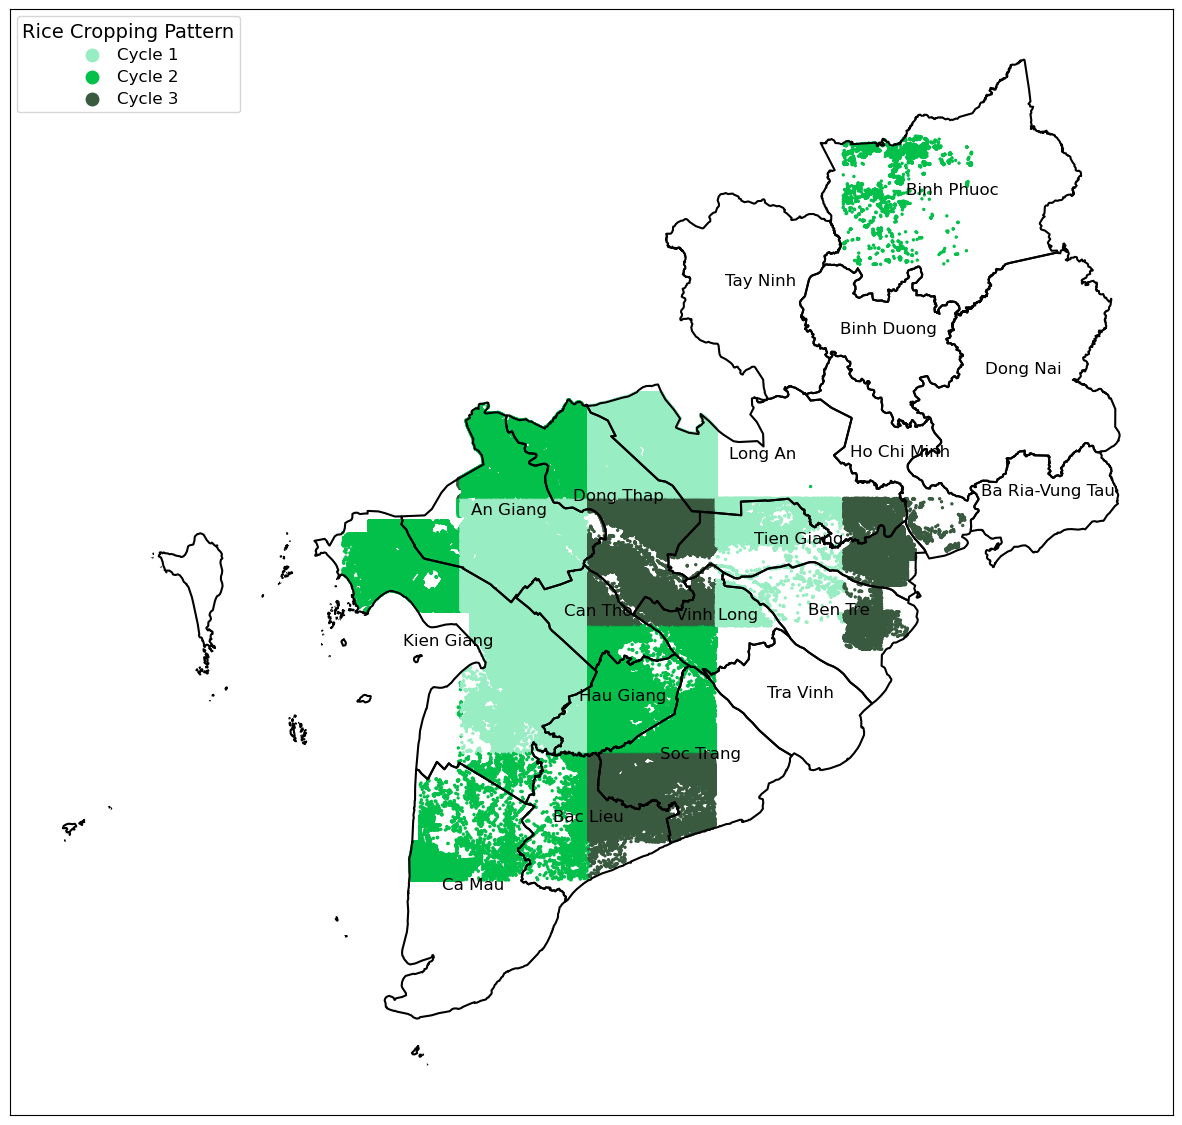

In [7]:
# Create a custom colormap for discrete values
colors = ['#99EDC3', '#03C04A', '#3A5A40']  # Green, Yellow, Red for 1, 2, 3 cycles
cmap = ListedColormap(colors)

# Create custom legend labels
legend_labels = {1: 'Cycle 1', 2: 'Cycle 2', 3: 'Cycle 3'}

fig, ax = plt.subplots(figsize=(15, 15))
poly.boundary.plot(color='black', ax=ax)
for idx, row in poly.iterrows():
        ax.annotate(text=row['NAME_1_EN'],
                    xy=(row['centroid_x'], row['centroid_y']),
                    xytext=(3, 3),  # Offset text slightly
                    textcoords="offset points",
                    ha='center',
                    fontsize=12,
                    color='black')

# Plot with discrete colormap
gdf.plot(column='cycles', cmap=cmap, categorical=True, legend=True, ax=ax, markersize=2,
         legend_kwds={'title': 'Rice Cropping Pattern', 'loc': 'upper left'})

# Modify the legend labels and font sizes after plotting
legend = ax.get_legend()
# Increase title font size
legend.get_title().set_fontsize(14)  # Adjust title font size
# Modify labels and their font size
for i, text in enumerate(legend.get_texts()):
    text.set_text(legend_labels[i + 1])  # i + 1 because our values are 1-based
    text.set_fontsize(12)  # Adjust label font size

ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
# plt.title("Study Area and Rice Cropping Cycles", fontsize=20)



In [86]:
df = pd.read_csv(r"D:\Work\ADB\SAR\datasets\paper figures\FIRMS47_mapping.csv")
df.columns = df.columns.str.upper()
asia = df[df['ASIA=1, FRP=2'] == 1]
frp = df[df['ASIA=1, FRP=2'] == 2]

asia.head()


,GID_1,NAME_1,GID_2,NAME_2,COUNTRY,"ASIA=1, FRP=2"
8635,BTN.10_1,Punakha,BTN.10.10_1,Toepisa,Bhutan,1
8636,BTN.10_1,Punakha,BTN.10.11_1,Toewang,Bhutan,1
8637,BTN.10_1,Punakha,BTN.10.1_1,Barp,Bhutan,1
8638,BTN.10_1,Punakha,BTN.10.2_1,Chhubug,Bhutan,1
8639,BTN.10_1,Punakha,BTN.10.3_1,Dzomi,Bhutan,1


In [88]:
polys = []
for id in ['THA', 'LAO', 'MYS', 'KHM', 'IDN', 'CHN', 'VNM', 'PHL']:
    poly = gpd.read_file(rf"D:\Work\ADB\SAR\shapefiles\gadm41_{id}_0.json")
    polys.append(poly)

poly_df0 = gpd.GeoDataFrame(pd.concat(polys, axis=0).reset_index(drop=True))


polys = []
for id in ['THA', 'LAO', 'MYS', 'KHM', 'IDN', 'CHN', 'VNM', 'PHL']:
    poly = gpd.read_file(rf"D:\Work\ADB\SAR\shapefiles\gadm41_{id}_2.json")
    polys.append(poly)
poly_df2 = gpd.GeoDataFrame(pd.concat(polys, axis=0).reset_index(drop=True))

In [90]:
# asia = gpd.GeoDataFrame(pd.merge(asia, poly_df, on='GID_2', how='left'))
# asia = asia[asia['geometry'].notna()]
frp = gpd.GeoDataFrame(pd.merge(frp, poly_df2, on='GID_2', how='left'))



C:\Users\sonle\AppData\Local\Temp\ipykernel_43408\1900003615.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poly_df0['centroid_x'] = poly_df0.centroid.x
C:\Users\sonle\AppData\Local\Temp\ipykernel_43408\1900003615.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poly_df0['centroid_y'] = poly_df0.centroid.y


[]

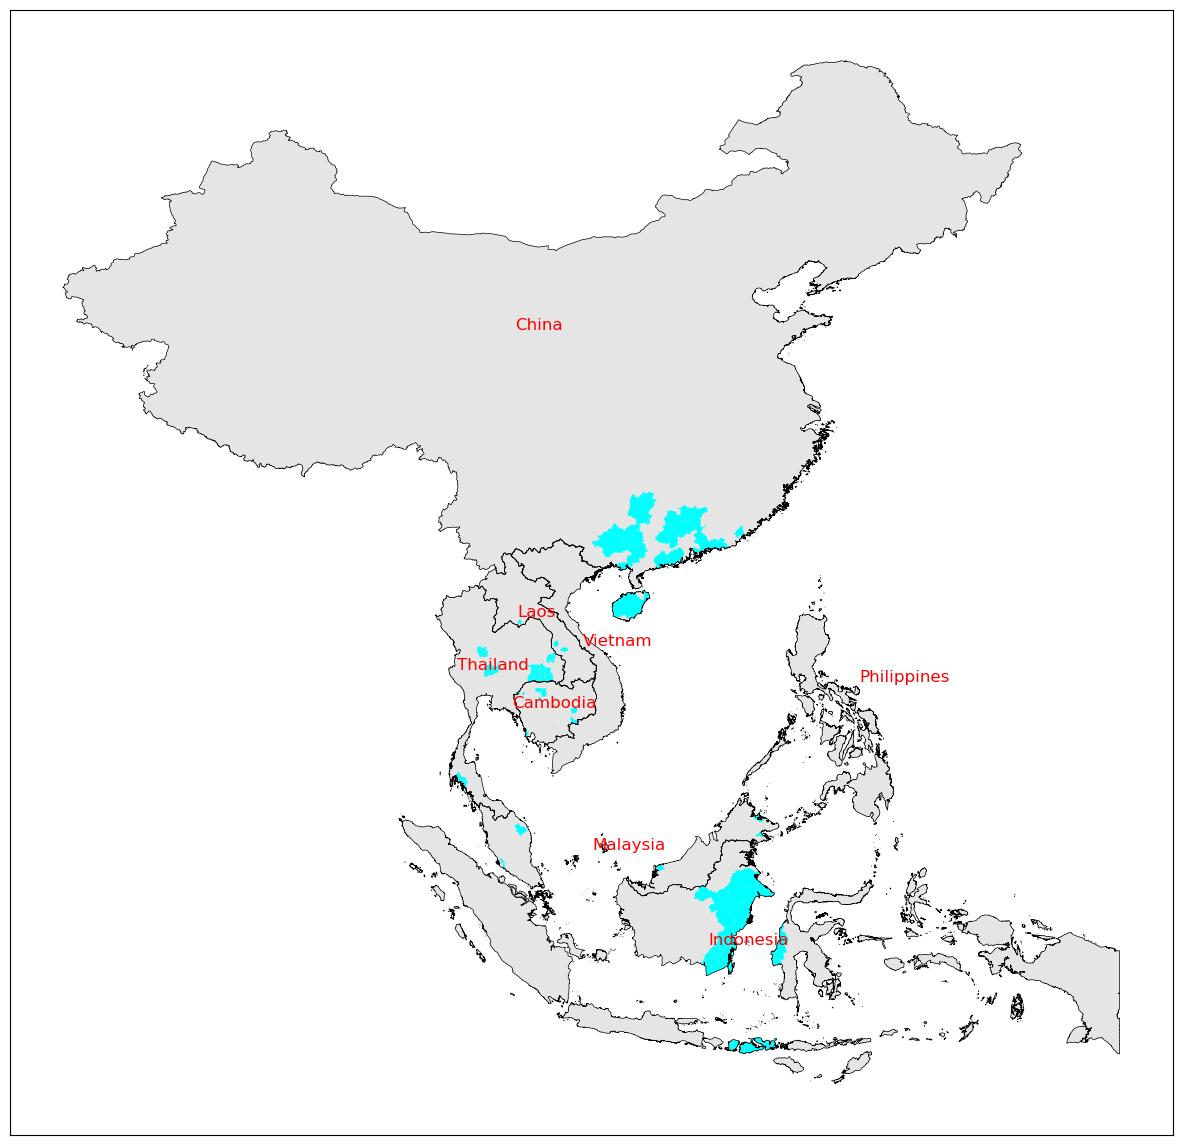

In [114]:
poly_df0['centroid_x'] = poly_df0.centroid.x
poly_df0['centroid_y'] = poly_df0.centroid.y
poly_df0 = poly_df0.drop_duplicates(subset=['COUNTRY'], keep='first')

fig, ax = plt.subplots(figsize=(15, 15))
poly_df0.plot(ax=ax, linewidth=0.5, color='grey', alpha=0.2)
poly_df0.boundary.plot(ax=ax, linewidth=0.5, color='black', alpha=1)
for idx, row in poly_df0.iterrows():
        if row['COUNTRY'] == 'Philippines':
                ax.annotate(text=row['COUNTRY'],
                    xy=(row['centroid_x'], row['centroid_y']),
                    xytext=(50, 30),  # Offset text slightly
                    textcoords="offset points",
                    ha='center',
                    fontsize=12,
                    color='red')
        elif row['COUNTRY'] == 'Vietnam':
                ax.annotate(text=row['COUNTRY'],
                    xy=(row['centroid_x'], row['centroid_y']),
                    xytext=(30, 0),  # Offset text slightly
                    textcoords="offset points",
                    ha='center',
                    fontsize=12,
                    color='red')
        else:
                ax.annotate(text=row['COUNTRY'],
                    xy=(row['centroid_x'], row['centroid_y']),
                    xytext=(0, 0),  # Offset text slightly
                    textcoords="offset points",
                    ha='center',
                    fontsize=12,
                    color='red')



frp.plot(ax=ax, linewidth=1, color='aqua', alpha=1)

ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])